# EJERCICIO 
# Aprendizaje no supervisado: Clustering.

## *Segmentación de clientes*


En el aprendizaje no supervisado, la tarea clásica es el **análisis de clusters** (grupos) en el que se encuentran patrones o grupos ocultos en los datos. La mayoría de las veces las tareas de aprendizaje no supervisado tienen una *solución abierta*, por lo que hay que interpretar los resultados y comprobar si tienen sentido.

**Objetivo:** En este ejemplo, se realizará un clustering de datos sobre clientes de una empresa de comestibles. La segmentación de clientes es la práctica de separar a los clientes en grupos que reflejen similitudes. Se dividirá a los clientes en segmentos para optimizar la importancia de cada uno de ellos. Así, la empresa podrá modificar los productos en función de las distintas necesidades y comportamientos de los clientes. También ayuda a la empresa a atender las preocupaciones de distintos tipos de clientes.

<img src="Data/market_segmentation.png" alt="market_segmentation" class="bg-primary" width="800px">

### Antes de empezar:

* En el archivo **marketing_campaign.csv** se encuentra el conjunto de datos de entrada de este ejemplo (atributos). 
* **NO** existen las etiquetas en el Aprendizaje **NO Supervisado**. 

## **1. Importar librerías y datos**

In [1]:
# Importar librerías
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## **2. Comprender los datos**

Es necesario visualizar y comprender los datos con los que vamos a trabajar, así como conocer sus características. 

1. ¿Cuántos datos hay? ¿Cuántos atributos hay en los datos?  
2. ¿Qué significan?
3. ¿Falta algún dato?
4. Resumen estadístico del conjunto de datos de entrada.

In [31]:
# Primera visualización del dataset
df_clientes = pd.read_csv('Data/marketing_campaign.csv', sep="\t")
df_clientes.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**1. ¿Cuántos datos hay? ¿Cuántos atributos hay en los datos?**

In [32]:
# Dimensión de los datos de entrada (filas x columnas)
df_clientes.shape

(2240, 29)

In [33]:
# Ya hemos visto el "head", vamos a ver el "tail"
df_clientes.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


**2. ¿Qué significan?**

In [34]:
# Información sobre el dataset: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

# También podemos obtener el nombre de las columnas
df_clientes.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [35]:
# Se comprueba el tipo de variable de cada columna
df_clientes.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

**3. Resumen estadístico del conjunto de datos de entrada:** La estadística descriptiva recolecta y analiza el conjunto de datos de entrada con el objetivo de describir las características y comportamientos de este conjunto mediante las siguientes medidas resumen: número total de observaciones (count), media (mean), desviación estándar (std), valor mínimo (min), valor máximo (max) y los valores de los diferentes cuartiles (25%, 50%, 75%).

In [36]:
# Evaluamos la naturaleza de los datos con datos estadísticos descriptivos
df_clientes.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


**4. ¿Falta algún dato?** Se comprueba si falta algún dato, y de ser así, se realiza el recuento de celdas vacías en cada atributo.

In [37]:
df_clientes.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

## **3. Limpieza de datos**

Antes de empezar a trabajar con los datos, estos se tienen que limpiar (anteriormente ya se han eliminado los NaNs) y transformar en otros features en caso de ser necesario 

In [38]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

De la función `df_clientes.info()` vemos que no tenemos ningun valor nulo, aunque en la columna 'Income' tenemos 2216 muestras en vez de 2240. También vemos que la columna 'Dt_Customer' está en formato `object` en vez de `DateTime` y que hay 2 columnas más con formato `object`, en las cuales tendremos que codificar para que el código pueda entenderlas.

**¿Qué hacemos con los NaN?**

In [104]:
# Una solución fácil para este dataset (>2000 filas) seria eliminar las filas con valores NaN
# Creamos una copia de nuestro df para no perder el dataset inicial
df_clean = df_clientes.copy()
df_clean.dropna(inplace=True)
df_clean.shape
# Otras opciones?

(2216, 29)

In [105]:
# Comprobamos que ya no faltan más valores
df_clean.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

**Queremos que *Dt_Customer* esté en formato datetime.** Este formato nos permitirá aplicar funciones para identificar el dia/mes/año y otros métodos específicos para este tipo de variables.

In [106]:
df_clean["Dt_Customer"]
# Vemos que los datos están en formato DD-MM-YYYY. Tenemos que especificarlo para que la función entienda como formatear los datos.

0       04-09-2012
1       08-03-2014
2       21-08-2013
3       10-02-2014
4       19-01-2014
           ...    
2235    13-06-2013
2236    10-06-2014
2237    25-01-2014
2238    24-01-2014
2239    15-10-2012
Name: Dt_Customer, Length: 2216, dtype: object

In [107]:
# Cambiamos el formato de la columna 'Dt_Customer' a DateTime
df_clean["Dt_Customer"] = pd.to_datetime(df_clean["Dt_Customer"], format="%d-%m-%Y")

# Para que tenga más sentido, cambiamos la fecha en la que una persona se hizo cliente por una variable que cuente
# los días que esa persona lleva siendo cliente. e.g.: ["Customer_For"]
fechas = list(df_clean["Dt_Customer"])
ultima_fecha = max(fechas)
df_clean["Customer_For_days"] = (ultima_fecha - df_clean["Dt_Customer"]).dt.days

df_clean.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_For_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,161


**Las columnas con formato *object* son datos categóricos y tienen que tranformarse a valores numéricos**. ¿Cómo lo hacemos?

In [108]:
print("Total categories in the feature Marital_Status:\n", df_clean["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", df_clean["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


***Marital_Status.*** Opciones:
- Integer encoding.
- One-hot encoding (en 1 o múltiples columnas).

In [109]:
# Primero reducimos el Martial_Status a 2 variables (pareja/solo)
df_clean["Living_With"]=df_clean["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

# Ahora hacemos one-hot encoding creando la columna 'Partner'
df_clean["Partner"] = df_clean['Living_With'].map({"Alone": 0, "Partner":1})

# Eliminamos las columnas "Marital_Status" y "Partner"
df_clean.drop(columns=['Marital_Status', 'Living_With'], inplace=True)
df_clean

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_For_days,Partner
0,5524,1957,Graduation,58138.0,0,0,2012-09-04,58,635,88,...,0,0,0,0,0,3,11,1,663,0
1,2174,1954,Graduation,46344.0,1,1,2014-03-08,38,11,1,...,0,0,0,0,0,3,11,0,113,0
2,4141,1965,Graduation,71613.0,0,0,2013-08-21,26,426,49,...,0,0,0,0,0,3,11,0,312,1
3,6182,1984,Graduation,26646.0,1,0,2014-02-10,26,11,4,...,0,0,0,0,0,3,11,0,139,1
4,5324,1981,PhD,58293.0,1,0,2014-01-19,94,173,43,...,0,0,0,0,0,3,11,0,161,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,61223.0,0,1,2013-06-13,46,709,43,...,0,0,0,0,0,3,11,0,381,1
2236,4001,1946,PhD,64014.0,2,1,2014-06-10,56,406,0,...,0,0,1,0,0,3,11,0,19,1
2237,7270,1981,Graduation,56981.0,0,0,2014-01-25,91,908,48,...,1,0,0,0,0,3,11,0,155,0
2238,8235,1956,Master,69245.0,0,1,2014-01-24,8,428,30,...,0,0,0,0,0,3,11,0,156,1


***Education***. Opciones:
- Integer encoding.
- One-hot encoding (en 1 o múltiples columnas).

In [110]:
# Podemos mapear directamente las variables usando integer encoding
df_clean["Education_int"] = df_clean['Education'].map({"Basic": 0, "2n Cycle":1, "Graduation": 2, "Master": 3, "PhD": 4})

# Eliminamos la columna "Education"
df_clean.drop(columns=['Education'], inplace=True)
df_clean

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_For_days,Partner,Education_int
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,0,0,0,0,3,11,1,663,0,2
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,0,0,3,11,0,113,0,2
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,0,0,3,11,0,312,1,2
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,0,0,3,11,0,139,1,2
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,0,0,3,11,0,161,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,61223.0,0,1,2013-06-13,46,709,43,182,...,0,0,0,0,3,11,0,381,1,2
2236,4001,1946,64014.0,2,1,2014-06-10,56,406,0,30,...,0,1,0,0,3,11,0,19,1,4
2237,7270,1981,56981.0,0,0,2014-01-25,91,908,48,217,...,0,0,0,0,3,11,0,155,0,2
2238,8235,1956,69245.0,0,1,2014-01-24,8,428,30,214,...,0,0,0,0,3,11,0,156,1,3


**De las variables numéricas también podemos derivar características informativas para nuestro modelo**

A continuación, realizaremos los siguientes pasos para crear algunos Features nuevos:

* **"Year_Birth"** no es muy informativo: Extraemos la edad **("Age")** del cliente.
* Crear otra función **"Spent"** que indique la cantidad total gastada por el cliente en varias categorías en un periodo de dos años.
* Crear una función **"Children"** para indicar el total de hijos de un hogar, es decir, niños **("Kidhome")** y adolescentes **("Teenhome")**.
* Para obtener una mayor claridad del hogar, crear una característica que indique **"Family_Size"**.
* Crear una característica **"Is_Parent"** para indicar la situación de paternidad
* Tambien eliminaremos algunas de las características redundantes

In [111]:
# Feature Engineering
# Age of customer today 
df_clean["Age"] = ultima_fecha.year-df_clean["Year_Birth"]

# Total spendings on various items
df_clean["Spent"] = df_clean["MntWines"]+ df_clean["MntFruits"]+ df_clean["MntMeatProducts"]+ df_clean["MntFishProducts"]+ df_clean["MntSweetProducts"]+ df_clean["MntGoldProds"]

# Feature indicating total children living in the household
df_clean["Children"]=df_clean["Kidhome"]+df_clean["Teenhome"]

# Feature for total members in the household
df_clean["Family_Size"] = df_clean["Partner"] + 1 + df_clean["Children"]

# Feature pertaining parenthood
df_clean["Is_Parent"] = np.where(df_clean.Children> 0, 1, 0)

# Cambiamos algunos nombres de columnas
df_cluster = df_clean.rename(columns={"MntWines": "SpentWines","MntFruits":"SpentFruits","MntMeatProducts":"SpentMeat",
                                      "MntFishProducts":"SpentFish","MntSweetProducts":"SpentSweets","MntGoldProds":"SpentGold"})

# Dropping some of the redundant features
to_drop = ["Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
df_cluster = df_cluster.drop(to_drop, axis=1)
df_cluster

,Income,Kidhome,Teenhome,Recency,SpentWines,SpentFruits,SpentMeat,SpentFish,SpentSweets,SpentGold,...,Complain,Response,Customer_For_days,Partner,Education_int,Age,Spent,Children,Family_Size,Is_Parent
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,1,663,0,2,57,1617,0,1,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,113,0,2,60,27,2,3,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,312,1,2,49,776,0,2,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,139,1,2,30,53,1,3,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,161,1,4,33,422,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,381,1,2,47,1341,1,3,1
2236,64014.0,2,1,56,406,0,30,0,0,8,...,0,0,19,1,4,68,444,3,5,1
2237,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,155,0,2,33,1241,0,1,0
2238,69245.0,0,1,8,428,30,214,80,30,61,...,0,0,156,1,3,58,843,1,3,1


In [112]:
df_cluster.dtypes

Income                 float64
Kidhome                  int64
Teenhome                 int64
Recency                  int64
SpentWines               int64
SpentFruits              int64
SpentMeat                int64
SpentFish                int64
SpentSweets              int64
SpentGold                int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
Customer_For_days        int64
Partner                  int64
Education_int            int64
Age                      int64
Spent                    int64
Children                 int64
Family_Size              int64
Is_Parent                int32
dtype: object

Ahora, vamos a visualizar los datos para tener más información de ellos.

**1. Histograma**

Respresentación gráfica de cada uno de los atributos en forma de barras, donde la superficie de la barra es proporcional a la frecuencia de los valores representados.

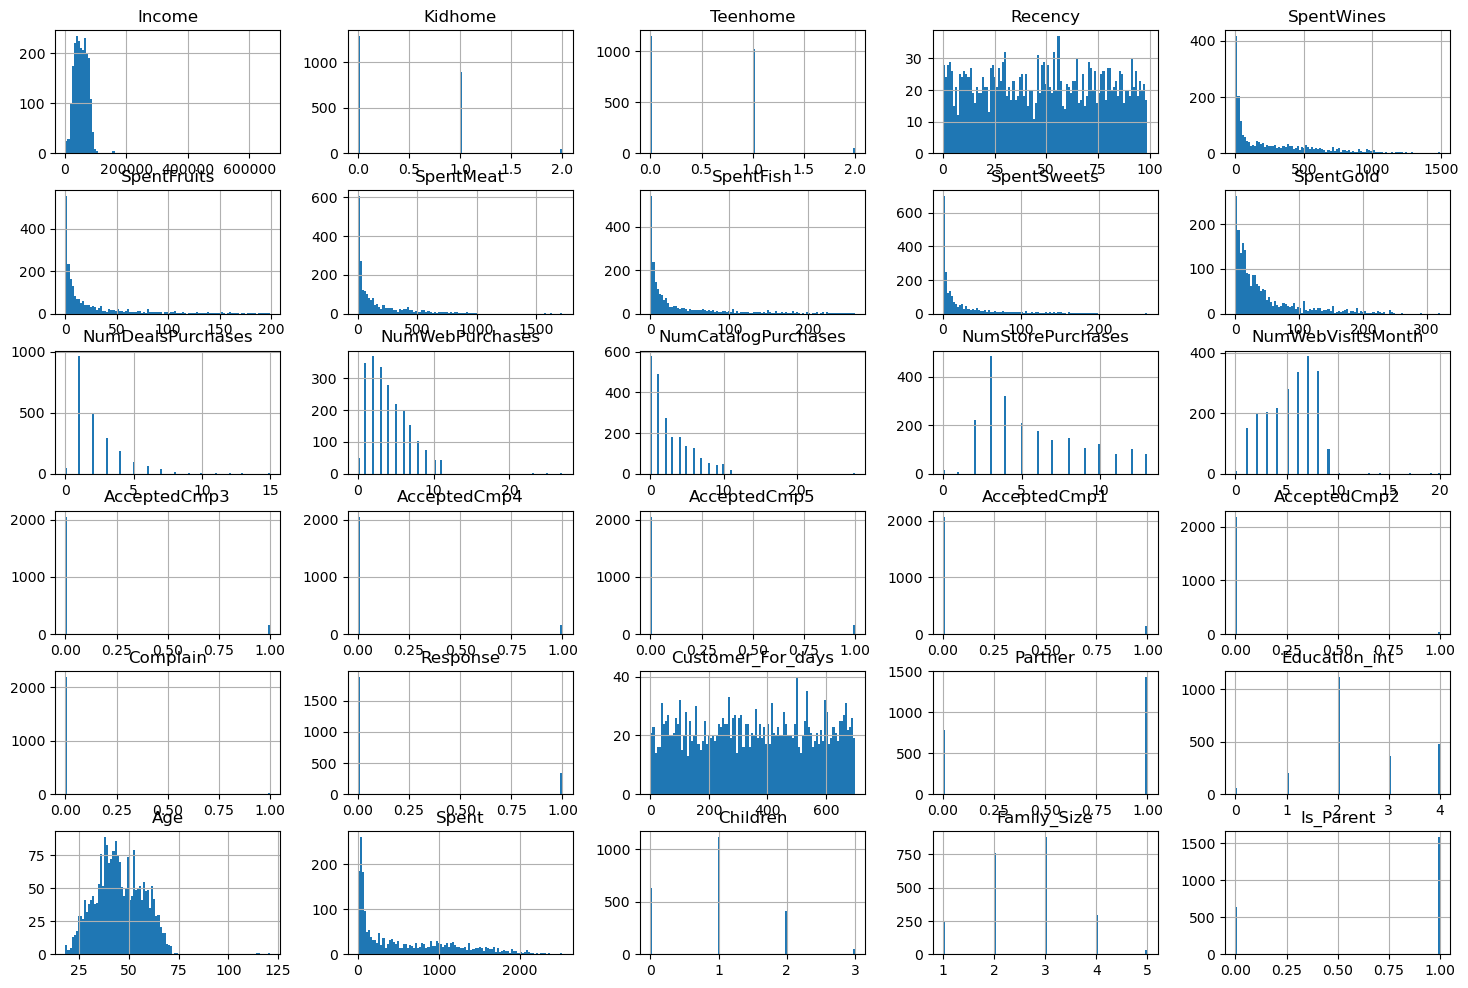

In [113]:
histograma = df_cluster.hist(xlabelsize=10, ylabelsize=10, bins=100, figsize=(18, 12))

Algunas categorias (como Income y Age) parecen tener outliers. Vamos a comprobarlo con un boxplot y en caso de que sea necesario, eliminamos los outliers.

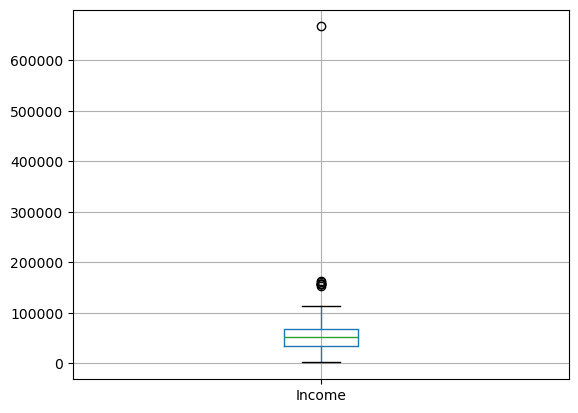

In [114]:
boxplot = df_cluster.boxplot(column=['Income'])

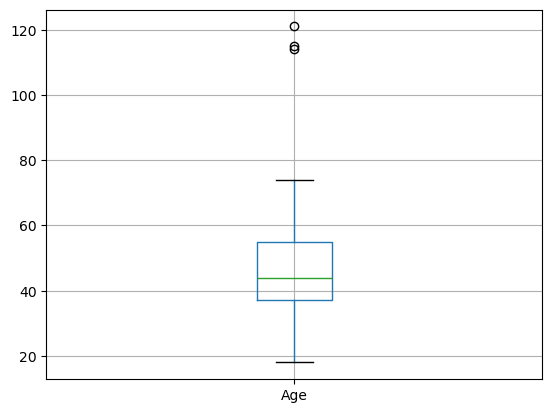

In [115]:
boxplot = df_cluster.boxplot(column=['Age'])

In [116]:
# Tiene sentido eliminar los outliers de estas columnas?
df_cluster = df_cluster[(df_cluster["Age"]<100)]
df_cluster.reset_index(drop=True, inplace=True)
df_cluster

,Income,Kidhome,Teenhome,Recency,SpentWines,SpentFruits,SpentMeat,SpentFish,SpentSweets,SpentGold,...,Complain,Response,Customer_For_days,Partner,Education_int,Age,Spent,Children,Family_Size,Is_Parent
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,1,663,0,2,57,1617,0,1,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,113,0,2,60,27,2,3,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,312,1,2,49,776,0,2,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,139,1,2,30,53,1,3,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,161,1,4,33,422,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,381,1,2,47,1341,1,3,1
2209,64014.0,2,1,56,406,0,30,0,0,8,...,0,0,19,1,4,68,444,3,5,1
2210,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,155,0,2,33,1241,0,1,0
2211,69245.0,0,1,8,428,30,214,80,30,61,...,0,0,156,1,3,58,843,1,3,1


Ahora, vamos a mirar la correlación entre variables (excluyendo los atributos categoricos).

<Axes: >

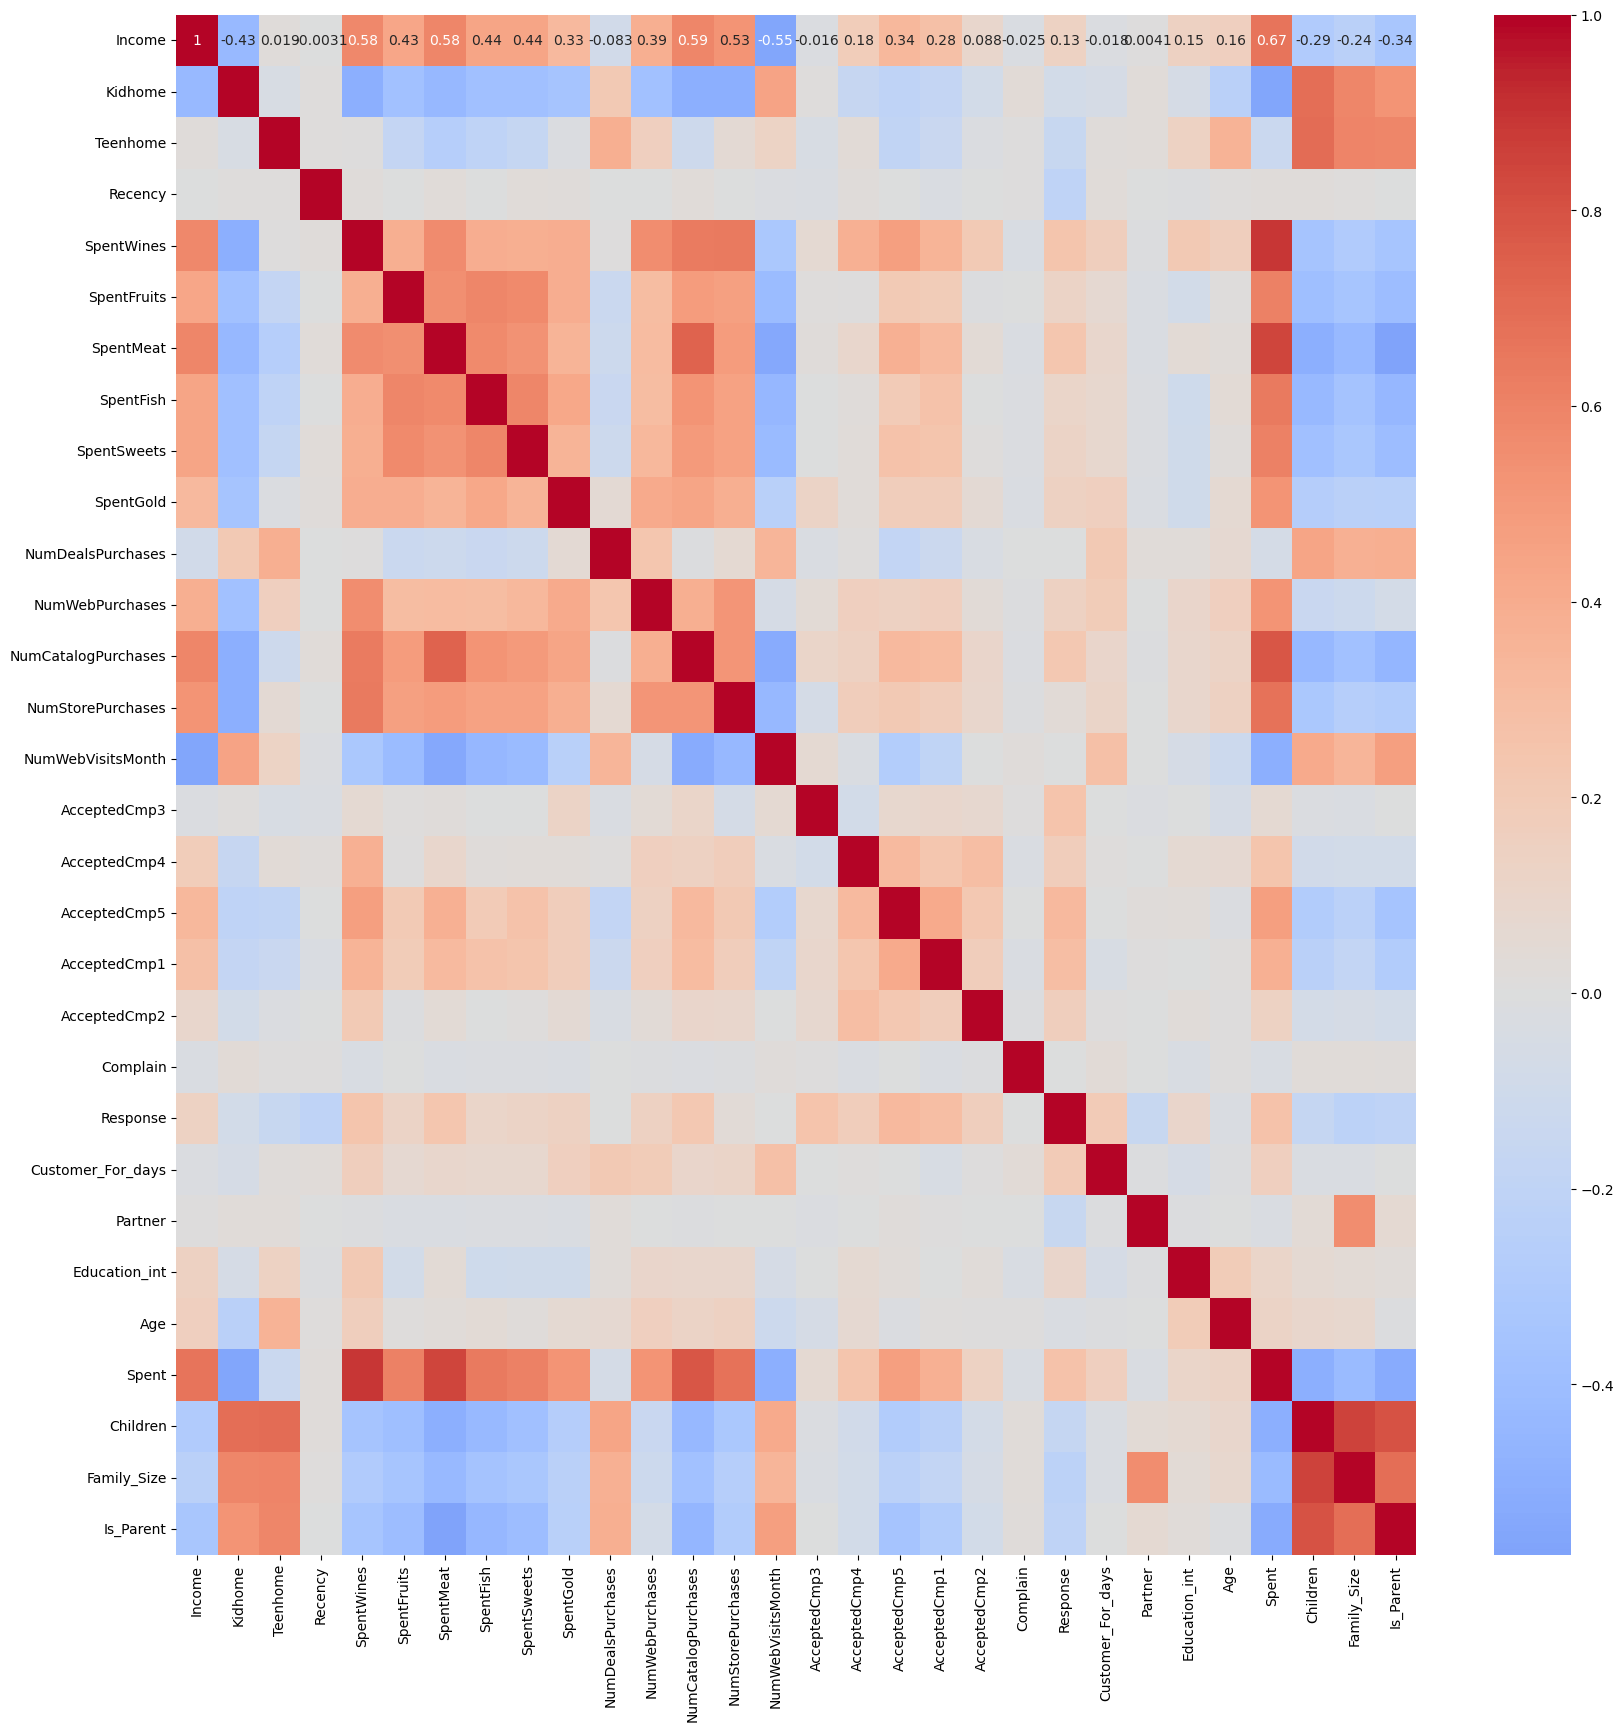

In [117]:
#correlation matrix
corrmat= df_cluster.corr()
plt.figure(figsize=(20,20))  
sns.heatmap(corrmat, annot=True, cmap='coolwarm', center=0)

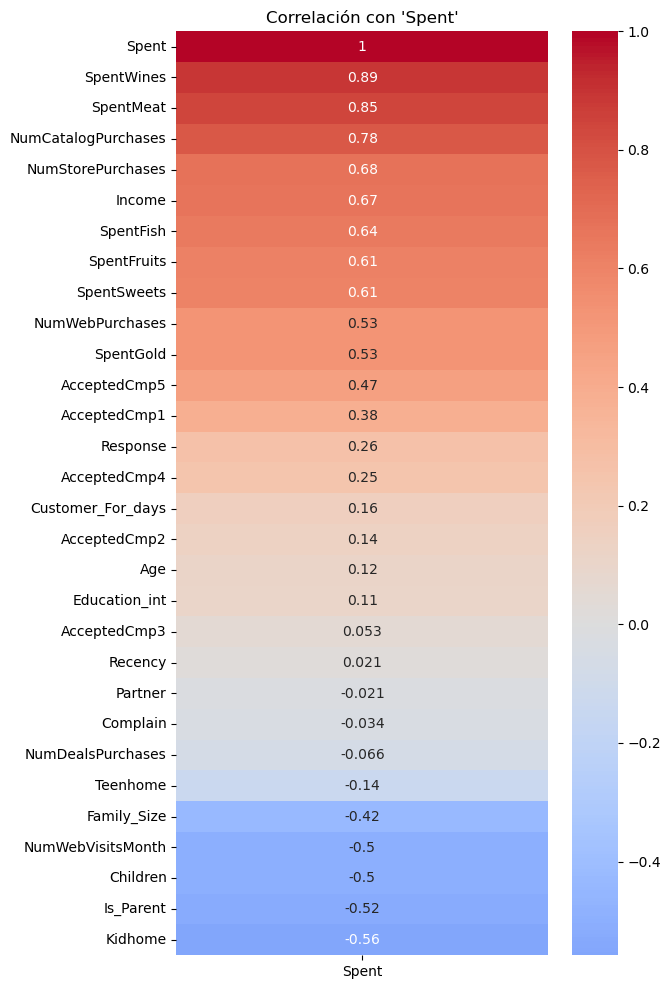

In [118]:
# Matriz de correlación solo con respecto a 'Spent'
corr_with_spent = df_cluster.corr()['Spent'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(6, 12))
sns.heatmap(corr_with_spent, annot=True, cmap='coolwarm', center=0)
plt.title("Correlación con 'Spent'")
plt.show()

## *4. Procesamiento de los datos*

1. Si no lo hemos hecho antes, encoding para las variables categóricas.
2. Escalar los datos usando el Standard Scaler.

**1. Encoding para las variables categóricas**. 

In [119]:
# Obtener lista de variables categóricas
cat = (df_cluster.dtypes == 'object')
cols_cat = list(cat[cat].index)
cols_cat

print("Variables categoricas en el dataset:", cols_cat)

Variables categoricas en el dataset: []


**Paso extra (opcional): reducimos el número de columnas para entender mejor el algoritmo**

Nos quedaremos solo con las siguientes columnas: 'Income', 'Spent', 'Age', 'Customer_For_days', 'Kidhome', 'NumCatalogPurchases', 'NumWebVisitsMonth' y 'Family_Size'

In [141]:
df_cluster_reduced = df_cluster.copy()
# df_cluster_reduced = df_cluster[['Income', 'Spent', 'Age', 'Customer_For_days', 'Kidhome', 'NumCatalogPurchases', 'NumWebVisitsMonth', 'Family_Size']].copy()
df_cluster_reduced.head()

,Income,Kidhome,Teenhome,Recency,SpentWines,SpentFruits,SpentMeat,SpentFish,SpentSweets,SpentGold,...,Complain,Response,Customer_For_days,Partner,Education_int,Age,Spent,Children,Family_Size,Is_Parent
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,1,663,0,2,57,1617,0,1,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,113,0,2,60,27,2,3,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,312,1,2,49,776,0,2,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,139,1,2,30,53,1,3,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,161,1,4,33,422,1,3,1


**2. Escalar los datos**. 

Se escalan los datos utilizando el método de *StandardScaler()*

In [142]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df_cluster_reduced.values.copy()
X_scale = pd.DataFrame(scaler.fit_transform(X))
X_scale

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.234435,-0.823208,-0.929307,0.310773,0.978107,1.552498,1.690807,2.454109,1.484200,0.852974,...,-0.095498,2.376057,1.527968,-1.350076,-0.458724,1.018785,1.676723,-1.264914,-1.758879,-1.581639
1,-0.234084,1.039532,0.908545,-0.380424,-0.872266,-0.637451,-0.718020,-0.650863,-0.633818,-0.733466,...,-0.095498,-0.420865,-1.189356,-1.350076,-0.458724,1.275248,-0.962927,1.404857,0.448948,0.632255
2,0.769733,-0.823208,-0.929307,-0.795142,0.358351,0.570796,-0.178264,1.339972,-0.146917,-0.036980,...,-0.095498,-0.420865,-0.206179,0.740699,-0.458724,0.334882,0.280531,-1.264914,-0.654965,-1.581639
3,-1.016592,1.039532,-0.929307,-0.795142,-0.872266,-0.561936,-0.655569,-0.504747,-0.585128,-0.752813,...,-0.095498,-0.420865,-1.060901,0.740699,-0.458724,-1.289387,-0.919763,0.069971,0.448948,0.632255
4,0.240593,1.039532,-0.929307,1.554927,-0.391881,0.419766,-0.218411,0.152777,-0.000847,-0.559344,...,-0.095498,-0.420865,-0.952208,0.740699,1.533732,-1.032923,-0.307165,0.069971,0.448948,0.632255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,0.356988,-0.823208,0.908545,-0.103945,1.197542,0.419766,0.067079,0.079719,2.214550,3.929119,...,-0.095498,-0.420865,0.134722,0.740699,-0.458724,0.163906,1.218520,0.069971,0.448948,0.632255
2209,0.467861,2.902273,0.908545,0.241653,0.299044,-0.662623,-0.610961,-0.687392,-0.658163,-0.694772,...,-0.095498,-0.420865,-1.653771,0.740699,1.533732,1.959151,-0.270642,2.739742,2.656775,0.632255
2210,0.188473,-0.823208,-0.929307,1.451248,1.787645,0.545625,0.223207,-0.102927,-0.366022,-0.385223,...,-0.095498,-0.420865,-0.981851,-1.350076,-0.458724,-1.032923,1.052504,-1.264914,-1.758879,-1.581639
2211,0.675663,-0.823208,0.908545,-1.417219,0.364281,0.092532,0.209824,0.773771,0.072188,0.330610,...,-0.095498,-0.420865,-0.976911,0.740699,0.537504,1.104272,0.391761,0.069971,0.448948,0.632255


## 5. Construcción del modelo de aprendizaje NO supervisado: Clustering de consumos utilizando K-means

Se agrupan los datos utilizando el algoritmo [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

El algoritmo K-means necesita que se le indique el número de clústers en que se quieren agrupar los datos. Se ejecuta el algoritmo para varios clusters y luego se comparan los resultados utilizando el método Elbow, que indicará el número óptimo de clusters.

### ¿Cómo saber el número óptimo de clusters? Con el método de Elbow.
Se utiliza el [Método de Elbow] para ayudarnos a elegir el número óptimo de clusters. 

* Este método utiliza los valores de la inercia obtenidos tras aplicar el K-means a diferente número de Clusters (desde 1 a N Clusters), siendo la inercia la suma de las distancias al cuadrado de cada objeto del Cluster a su centroide.
* Para hacer uso de este método partimos del cálculo de la distorsión promedio de cada clúster, esto es la distancia de cada elemento con su centroide correspondiente.
* Buscamos la parte de la gráfica donde la línea es menos suave o cambia abruptamente lo que forma un “codo”.

[Método de Elbow]: https://jarroba.com/seleccion-del-numero-optimo-clusters/


<img src="Data/elbow_method.png" alt="elbow" class="bg-primary" width="400px">

In [143]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

elbow_method = []

# Evalúo el algoritmo K-means para un rango de [1,15] clústers 
n_cluster_list = range(1,15)

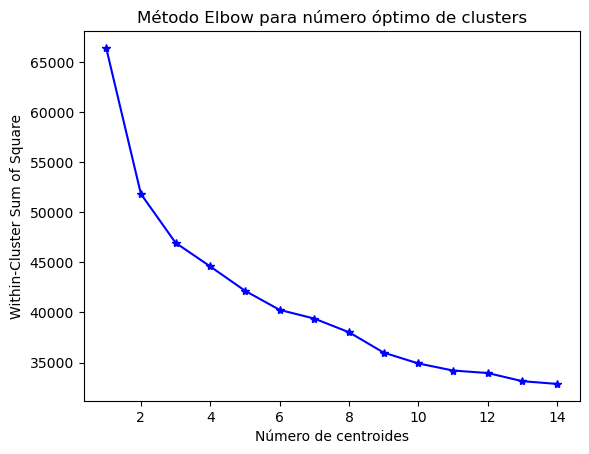

In [144]:
import matplotlib.pyplot as plt

# Iteración para evaluar K-means para diferentes números de clusters (n_clusters)
for n_cluster in n_cluster_list:
    kmeans = KMeans(n_clusters=n_cluster, random_state=0)
    cluster_found = kmeans.fit_predict(X_scale)
    elbow_method.append(kmeans.inertia_) 


# Gráfica del método de Elbow
plt.plot(n_cluster_list, elbow_method, 'b', marker='*')
plt.xlabel('Número de centroides')
plt.ylabel('Within-Cluster Sum of Square')
plt.title('Método Elbow para número óptimo de clusters')
plt.show()

# El número óptimo de clusters es de k=2, aunque podria ser interesante usar k=3 o incluso k=6

In [145]:
# Entreno el K-means para k=2, visto el resultado del método Elbow
kmeans = KMeans(n_clusters=2)
cluster_found = kmeans.fit_predict(X_scale)

df_cluster_def = df_cluster_reduced.copy()
df_cluster_def['cluster'] = pd.Series(cluster_found)
df_cluster_def

,Income,Kidhome,Teenhome,Recency,SpentWines,SpentFruits,SpentMeat,SpentFish,SpentSweets,SpentGold,...,Response,Customer_For_days,Partner,Education_int,Age,Spent,Children,Family_Size,Is_Parent,cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,1,663,0,2,57,1617,0,1,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,113,0,2,60,27,2,3,1,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,312,1,2,49,776,0,2,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,139,1,2,30,53,1,3,1,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,161,1,4,33,422,1,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,61223.0,0,1,46,709,43,182,42,118,247,...,0,381,1,2,47,1341,1,3,1,0
2209,64014.0,2,1,56,406,0,30,0,0,8,...,0,19,1,4,68,444,3,5,1,1
2210,56981.0,0,0,91,908,48,217,32,12,24,...,0,155,0,2,33,1241,0,1,0,0
2211,69245.0,0,1,8,428,30,214,80,30,61,...,0,156,1,3,58,843,1,3,1,0


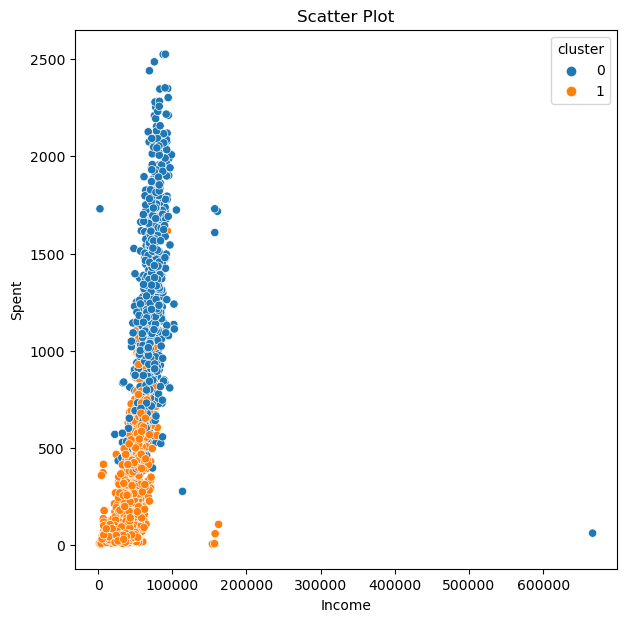

In [146]:
# Hacemos scatter plot entre 'Income' y 'Spent'
plt.figure(figsize=(7,7))
sns.scatterplot(x=df_cluster_def["Income"], y=df_cluster_def["Spent"], hue=df_cluster_def["cluster"])

# Estética del plot
plt.title('Scatter Plot', fontsize=12)
plt.xlabel('Income', fontsize=10)
plt.ylabel('Spent', fontsize=10)

plt.show()

K-means ha encontrado dos clúster con las siguientes características, mirando la gráfica anterior:
* Hay un cluster que concentra los consumidores que más gastan, los cuales en general tienen unos ingresos superiores
* El otro cluster concentra los consumidores con menores gastos.


### Extra: Encontrar el número óptimo de clústers mediante el Silhouette Score 

In [147]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Evalúo el algoritmo K-means para un rango de [2,15] clústers 
n_cluster_list = range(2,15)

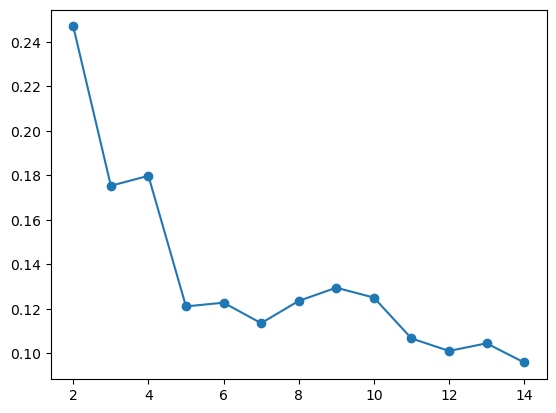

In [148]:
for n_cluster in n_cluster_list:
    kmeans = KMeans(n_clusters=n_cluster, random_state=0)
    cluster_found = kmeans.fit_predict(X_scale)
    silhouette_scores.append(silhouette_score(X_scale, kmeans.labels_, random_state=0))

silhouette_metric = pd.DataFrame(index=n_cluster_list, columns=['silhouette_score'], data=silhouette_scores)
plt.plot(silhouette_metric, marker='o')

In [149]:
# Entreno el K-means para k=4, ya que el resultado no es malo del todo y queremos probar un número de clústers distinto a 2
kmeans = KMeans(n_clusters=4)
cluster_found = kmeans.fit_predict(X_scale)

df_cluster_def = df_cluster.copy()
df_cluster_def['cluster'] = pd.Series(cluster_found)
df_cluster_def

,Income,Kidhome,Teenhome,Recency,SpentWines,SpentFruits,SpentMeat,SpentFish,SpentSweets,SpentGold,...,Response,Customer_For_days,Partner,Education_int,Age,Spent,Children,Family_Size,Is_Parent,cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,1,663,0,2,57,1617,0,1,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,113,0,2,60,27,2,3,1,3
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,312,1,2,49,776,0,2,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,139,1,2,30,53,1,3,1,3
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,161,1,4,33,422,1,3,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,61223.0,0,1,46,709,43,182,42,118,247,...,0,381,1,2,47,1341,1,3,1,1
2209,64014.0,2,1,56,406,0,30,0,0,8,...,0,19,1,4,68,444,3,5,1,1
2210,56981.0,0,0,91,908,48,217,32,12,24,...,0,155,0,2,33,1241,0,1,0,0
2211,69245.0,0,1,8,428,30,214,80,30,61,...,0,156,1,3,58,843,1,3,1,1


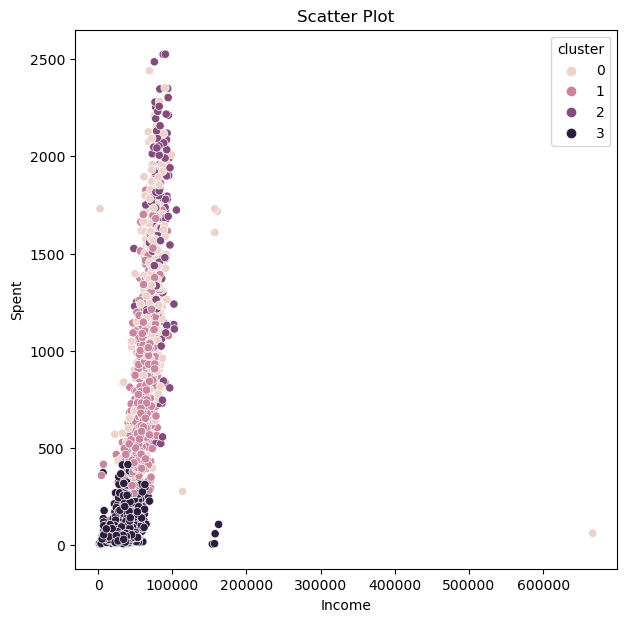

In [150]:
# Hacemos scatter plot entre 'Income' y 'Spent'
plt.figure(figsize=(7,7))
sns.scatterplot(x=df_cluster_def["Income"], y=df_cluster_def["Spent"], hue=df_cluster_def["cluster"])

# Estética del plot
plt.title('Scatter Plot', fontsize=12)
plt.xlabel('Income', fontsize=10)
plt.ylabel('Spent', fontsize=10)

plt.show()

## Validar los resultados con Dimensionality Reduction (PCA)
Principal Component Analysis (PCA) es un método estadístico que permite simplificar la complejidad de espacios muestrales con muchas dimensiones a la vez que conserva su información. En este caso, podemos trabajar con el dataset original (previo a reducirlo), ya que con este método se reducen las "features" conservando el máximo de información.

Repetimos los pasos seguidos anteriormente pero con todas las variables.

Una forma de validar los resultados del algoritmo clustering es mediante técnicas de dimensionality reduction. Hay que tener en cuenta es que el PCA no sabe nada de los grupos encontrados por K-means.

In [151]:
df_cluster.head()

,Income,Kidhome,Teenhome,Recency,SpentWines,SpentFruits,SpentMeat,SpentFish,SpentSweets,SpentGold,...,Complain,Response,Customer_For_days,Partner,Education_int,Age,Spent,Children,Family_Size,Is_Parent
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,1,663,0,2,57,1617,0,1,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,113,0,2,60,27,2,3,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,312,1,2,49,776,0,2,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,139,1,2,30,53,1,3,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,161,1,4,33,422,1,3,1


In [152]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df_cluster.values.copy()
X_scale = pd.DataFrame(scaler.fit_transform(X))
X_scale

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.234435,-0.823208,-0.929307,0.310773,0.978107,1.552498,1.690807,2.454109,1.484200,0.852974,...,-0.095498,2.376057,1.527968,-1.350076,-0.458724,1.018785,1.676723,-1.264914,-1.758879,-1.581639
1,-0.234084,1.039532,0.908545,-0.380424,-0.872266,-0.637451,-0.718020,-0.650863,-0.633818,-0.733466,...,-0.095498,-0.420865,-1.189356,-1.350076,-0.458724,1.275248,-0.962927,1.404857,0.448948,0.632255
2,0.769733,-0.823208,-0.929307,-0.795142,0.358351,0.570796,-0.178264,1.339972,-0.146917,-0.036980,...,-0.095498,-0.420865,-0.206179,0.740699,-0.458724,0.334882,0.280531,-1.264914,-0.654965,-1.581639
3,-1.016592,1.039532,-0.929307,-0.795142,-0.872266,-0.561936,-0.655569,-0.504747,-0.585128,-0.752813,...,-0.095498,-0.420865,-1.060901,0.740699,-0.458724,-1.289387,-0.919763,0.069971,0.448948,0.632255
4,0.240593,1.039532,-0.929307,1.554927,-0.391881,0.419766,-0.218411,0.152777,-0.000847,-0.559344,...,-0.095498,-0.420865,-0.952208,0.740699,1.533732,-1.032923,-0.307165,0.069971,0.448948,0.632255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,0.356988,-0.823208,0.908545,-0.103945,1.197542,0.419766,0.067079,0.079719,2.214550,3.929119,...,-0.095498,-0.420865,0.134722,0.740699,-0.458724,0.163906,1.218520,0.069971,0.448948,0.632255
2209,0.467861,2.902273,0.908545,0.241653,0.299044,-0.662623,-0.610961,-0.687392,-0.658163,-0.694772,...,-0.095498,-0.420865,-1.653771,0.740699,1.533732,1.959151,-0.270642,2.739742,2.656775,0.632255
2210,0.188473,-0.823208,-0.929307,1.451248,1.787645,0.545625,0.223207,-0.102927,-0.366022,-0.385223,...,-0.095498,-0.420865,-0.981851,-1.350076,-0.458724,-1.032923,1.052504,-1.264914,-1.758879,-1.581639
2211,0.675663,-0.823208,0.908545,-1.417219,0.364281,0.092532,0.209824,0.773771,0.072188,0.330610,...,-0.095498,-0.420865,-0.976911,0.740699,0.537504,1.104272,0.391761,0.069971,0.448948,0.632255


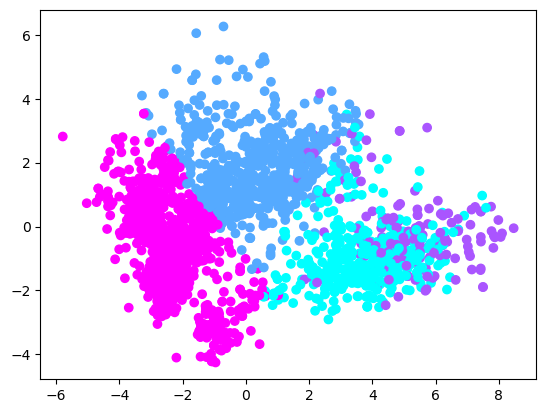

In [153]:
from sklearn.decomposition import PCA
import matplotlib.colors

pca = PCA(n_components=2)
results_pca = pca.fit_transform(X_scale)

plt.scatter(results_pca[:, 0], results_pca[:, 1],
            c = df_cluster_def['cluster'],
            cmap = 'cool'
            )
plt.show()